In [2]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patheffects as pe

from cosmoTransitions import pathDeformation, transitionFinder
from cosmoTransitions import pathDeformation

from scipy.optimize import minimize, brentq
from scipy.optimize import minimize_scalar
from scipy.optimize import shgo

import time

from xSM_Model import xSM

def physical_to_lagrangian(m1, m2, theta, v, u, lHS, lS):
    """
    Convert physical parameters to xSM Lagrangian parameters.

    Inputs
    ------
    m1, m2  : scalar mass eigenvalues (GeV), m1 < m2 convention
    theta   : mixing angle (rad)
    v, u    : Higgs and singlet vevs (GeV)
    lHS     : quartic portal lambda_HS
    lS      : singlet quartic lambda_S

    Outputs
    -------
    dict with keys: lH, muHS, mu3, muH2, muS2
    (lHS and lS are inputs, returned unchanged for completeness)
    """
    ct = np.cos(theta)
    st = np.sin(theta)
    
    Mhh = m1**2 * ct**2 + m2**2 * st**2
    Mss = m1**2 * st**2 + m2**2 * ct**2
    Mhs = (m1**2 - m2**2) * ct * st
    
    lH   = Mhh / (2.0 * v**2)

    muHS = Mhs / v  -  lHS * u

    # Relations don't hold if u=0
    if abs(u) > 1e-6:
        mu3 = (2.0*lS*u**2  -  Mss  -  muHS*v**2/(2.0*u)) / u
    else:
        mu3 = 0.0   

    # Mass parameters from tadpole conditions
    muH2 = lH*v**2  +  0.5*lHS*u**2  +  muHS*u
    if abs(u) > 1e-6:
        muS2 = 0.5*lHS*v**2  +  muHS*v**2/(2.0*u)  +  lS*u**2  -  mu3*u
    else:
        muS2 = 0.0

    return dict(lH=lH, lHS=lHS, muHS=muHS, lS=lS, mu3=mu3, muH2=muH2, muS2=muS2)

# Specific Parameters

## Original Example

In [30]:
v0 = 246.22
u0 = 200.0
params = physical_to_lagrangian(
    m1    = 125.20,   # GeV  -- SM-like Higgs, fixed
    m2    = 60.0,    # GeV  -- singlet-like scalar, not too heavy
    theta = 0.1,      # rad  -- moderate mixing, enhances cubic
    v     = v0,   # GeV
    u     = u0,     # GeV  -- Careful: If u is small and m2 is light, the potential can be unstable
    lHS   = 0.25,     #      -- portal, moderate
    lS    = 0.125,      #      -- large singlet self-coupling strengthens barrier
)

print(params)
lH   = params["lH"]
lHS  = params["lHS"]
muHS = params["muHS"]
lS   = params["lS"]
mu3  = params["mu3"]
muH2 = params["muH2"]
muS2 = params["muS2"]

model = xSM(**{k: params[k] for k in ['lH','lHS','muHS','lS','mu3']}, v=v0, u=u0)
v = model.v_os
u = model.u_os

{'lH': 0.12828762180611472, 'lHS': 0.25, 'muHS': -45.12846211493056, 'lS': 0.125, 'mu3': 65.59676910404056, 'muH2': 3751.653359537917, 'muS2': -7381.020026568172}


### Tree Level Analysis

In [6]:
# D_h(h)

s_min = np.linspace(0, 400, 1000)
h_plus  = np.full_like(s_min, np.nan)
h_minus = np.full_like(s_min, np.nan)

radicand = -s_min**2 * lHS + 2*muH2 - 2*s_min*muHS
valid = radicand >= 0
h_plus[valid]  =  np.sqrt(radicand[valid]) / (np.sqrt(2) * np.sqrt(lH))
h_minus[valid] = -np.sqrt(radicand[valid]) / (np.sqrt(2) * np.sqrt(lH))

In [8]:
# Minima at h=0

Radicand = mu3**2+4*lS*muS2
if Radicand >= 0:
    S1 = (mu3+Radicand**0.5)/(2*lS)
    S2 = (mu3-Radicand**0.5)/(2*lS)
    SignS1 = -muS2 - 2*mu3*(S1) + 3*lS*(S1)**2
    SignS2 = -muS2 - 2*mu3*(S2) + 3*lS*(S2)**2
    if SignS1 > 0:
        print(f"S1 (0,{S1:.2f}) is a minimum")
    if SignS2 > 0:
        print(f"S2 (0,{S2:.2f}) is a minimum")

S1 (0,361.38) is a minimum


In [14]:
# Minima at D_h(s)

sp = (-muHS+(2*lHS*muH2+muHS**2)**0.5)/(lHS)
sm = (-muHS-(2*lHS*muH2+muHS**2)**0.5)/(lHS)
SPath = np.linspace(sm,sp,500)

Vs0 = -0.5*muS2*SPath**2-mu3/3*SPath**3+lS/4*SPath**4

Vs = (-(muH2**2)/(4*lH)
      + SPath*(muH2*muHS)/(2*lH)
      - SPath**2*(-12*lHS*muH2 + 12*muHS**2 + 24*lH*muS2)/(48*lH)
      - SPath**3*(16*lH*mu3 + 12*lHS*muHS)/(48*lH)        
      - SPath**4*(3*lHS**2 - 12*lH*lS)/(48*lH))

DVs = (+ (muH2*muHS)/(2*lH)
      - 2*SPath*(-12*lHS*muH2 + 12*muHS**2 + 24*lH*muS2)/(48*lH)
      - 3*SPath**2*(16*lH*mu3 + 12*lHS*muHS)/(48*lH)        
      - 4*SPath**3*(3*lHS**2 - 12*lH*lS)/(48*lH))

a = -4*(3*lHS**2 - 12*lH*lS)/(48*lH)
b = -3*(16*lH*mu3 + 12*lHS*muHS)/(48*lH)
c = -2*(-12*lHS*muH2 + 12*muHS**2 + 24*lH*muS2)/(48*lH)
d = (muH2*muHS)/(2*lH)
X = np.roots([a, b, c, d])
root_s = X[np.abs(X.imag) < 1e-8].real
root_hp  =  np.sqrt(-root_s**2 * lHS + 2*muH2 - 2*root_s*muHS) / (np.sqrt(2) * np.sqrt(lH))
root_hm  = -np.sqrt(-root_s**2 * lHS + 2*muH2 - 2*root_s*muHS) / (np.sqrt(2) * np.sqrt(lH))
print(f"{root_hp}, {root_s}")

[246.22], [200.]


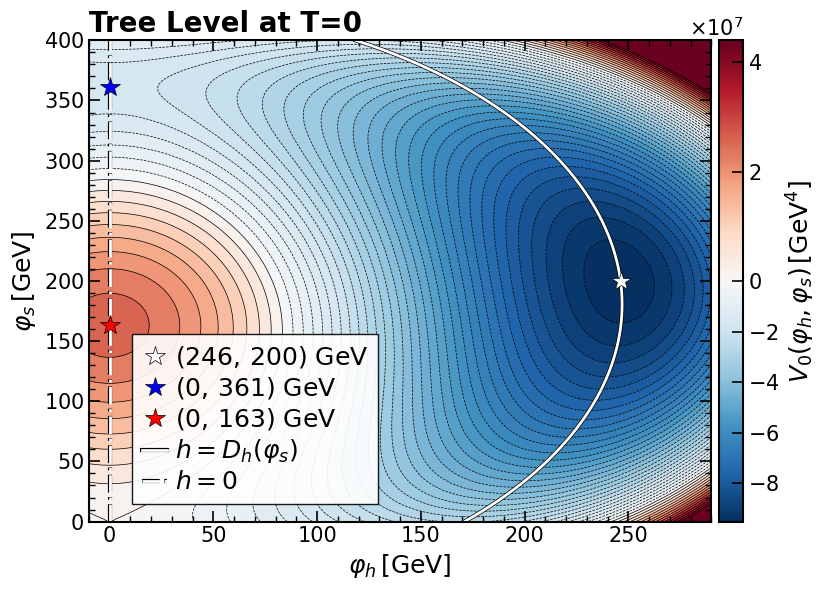

In [24]:
h_vals = np.linspace(-10, 290, 200)
s_vals = np.linspace(0, 400, 200)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.V0(X_grid).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 99))
V_shifted = V_plot - model.V0(np.array([[0.0, 0.0]]))

norm = TwoSlopeNorm(vcenter=0, vmin=V_shifted.min(), vmax=V_shifted.max()) # Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=50, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=50, colors='k', linewidths=0.5, alpha=1)
ax.plot(root_hp[0], root_s[0], 'w*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$({root_hp[0]:.0f},\,{root_s[0]:.0f})$ GeV')
ax.plot(0, S1, 'b*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$({0},\,{S1:.0f})$ GeV')
ax.plot(0, S2, 'r*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$({0},\,{S2:.0f})$ GeV')
ax.plot(h_plus, s_min, label=r'$h=D_h(\varphi_s)$', color='w', lw=2, ls='-', path_effects=[pe.Stroke(linewidth=3, foreground='black'), pe.Normal()])
ax.plot(h_plus-h_plus, s_min, label=r'$h=0$', color='w', lw=2, ls='-.', path_effects=[pe.Stroke(linewidth=3, foreground='black'), pe.Normal()])

ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_{0}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower left", bbox_to_anchor=(0.05, 0.01),ncol = 1, edgecolor="black", framealpha=0.9, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Tree Level at T=0", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures\TL_Contour.pdf", format="pdf", bbox_inches="tight")
plt.show()

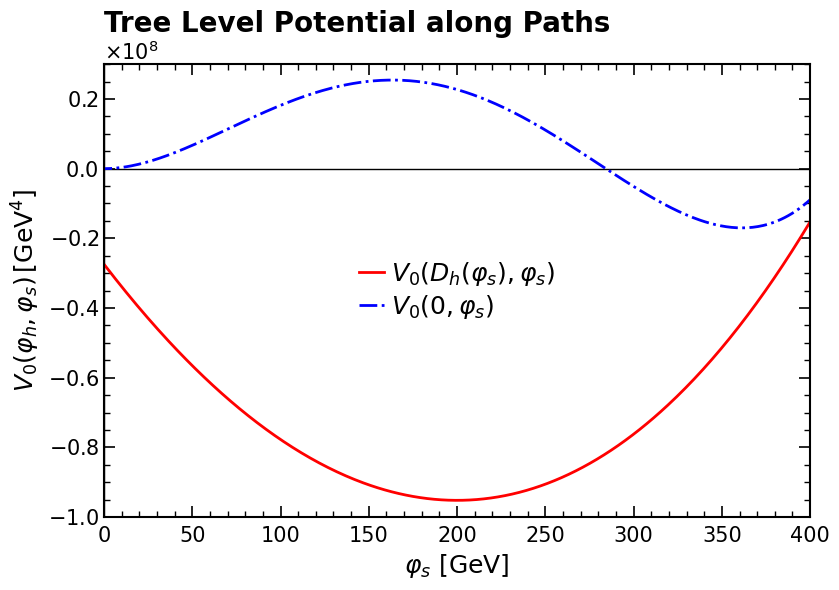

In [26]:
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(SPath, Vs, label=r'$V_{0}\left(D_h(\varphi_s),\varphi_s\right)$', color='r', lw=2, ls='-')
ax.plot(SPath, Vs0, label=r'$V_{0}\left(0,\varphi_s\right)$', color='b', lw=2, ls='-.')

ax.set_xlim(0, 400)
ax.set_ylim(-1e8, 0.3e8)

ax.set_xlabel(r'$\varphi_s$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_{0}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "center", bbox_to_anchor=(0.5, 0.5),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Tree Level Potential along Paths", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures\TL_Path.pdf", format="pdf", bbox_inches="tight")
plt.show()

### One Loop Coleman weinberg

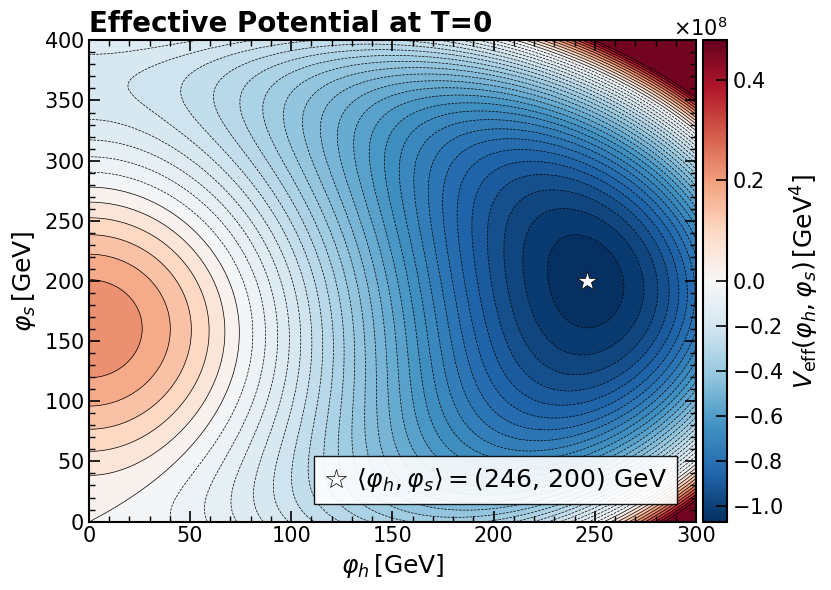

In [57]:
# Grid in (h, s)
h_vals = np.linspace(0, 300, 200)
s_vals = np.linspace(0, 400, 200)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.Vtot(X_grid, 0.0).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 99))
V_shifted = V_plot - model.Vtot(np.array([[0.0, 0.0]]), 0.0)

norm = TwoSlopeNorm(vcenter=0, vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=50, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=50, colors='k', linewidths=0.5, alpha=1)
ax.plot(v, u, 'w*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$\langle\varphi_h, \varphi_s\rangle = ({v:.0f},\,{u:.0f})$ GeV')

ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_\mathrm{eff}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0.9, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Effective Potential at T=0", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(r"Figures\CW_Contour.pdf", format="pdf", bbox_inches="tight")
plt.show()

### Phase Transition

In [43]:
trans = model.calcTcTrans()
Tc   = trans[0]['Tcrit']
high = trans[0]['high_vev']
low  = trans[0]['low_vev']
xi_c = abs(low[0] - high[0]) / Tc
print(f"Tc = {Tc:.2f} GeV  |  xi_c = {xi_c:.2f}")

Tracing phase starting at x = [246.22000044 200.00000251] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
.....................................................................................................................................................................................................................................................................
Tracing phase starting at x = [1.54851093e-05 3.48521610e+02] ; t = 127.63725517979087
Tracing minimum down
traceMinimum t0 = 127.637
.................................................................
Tracing minimum up
traceMinimum t0 = 127.637
...................................................................................................................................................................................
Tracing phase starting at x = [4.71993643e-03 3.49374867e+02] ; t = 123.88643434473488
Tracing minimum down
traceMinimum t0 = 123.886
..........
Tracing minimum up
traceMinimum t0 = 123.886
..........
Tc = 

In [45]:
model.findAllTransitions()
print()
print("The Model has",len(model.TnTrans),"transition(s)")

Tunneling from phase 1 to phase 0 at T=124.8866
high_vev = [-1.08938952e-03  3.49152453e+02]
low_vev = [150.77849284 274.94137934]
Path deformation converged. 16 steps. fRatio = 9.25734e-03
Path deformation converged. 12 steps. fRatio = 1.38035e-02
Path deformation converged. 1 steps. fRatio = 1.18454e-02
Tunneling from phase 1 to phase 0 at T=124.8871
high_vev = [-1.10408083e-03  3.49152335e+02]
low_vev = [150.77338631 274.94702769]
Path deformation converged. 16 steps. fRatio = 9.22525e-03
Path deformation converged. 12 steps. fRatio = 1.46965e-02
Path deformation converged. 1 steps. fRatio = 1.22444e-02
Tunneling from phase 1 to phase 0 at T=125.7614
high_vev = [8.99404191e-06 3.48954818e+02]
low_vev = [139.29778805 287.04626861]
Path deformation converged. 15 steps. fRatio = 7.33372e-03
Path deformation converged. 9 steps. fRatio = 1.78787e-02
Path deformation converged. 1 steps. fRatio = 1.11056e-02
Tunneling from phase 1 to phase 0 at T=126.1985
high_vev = [-4.68542739e-06  3.488

In [47]:
Trans = model.TnTrans[0]

Tc    = Trans['crit_trans']['Tcrit']
highc = Trans['crit_trans']['high_vev']
lowc  = Trans['crit_trans']['low_vev']
xic   = abs(lowc[0] - highc[0]) / Tc
Tn    = Trans['Tnuc']
highn = Trans['high_vev']
lown  = Trans['low_vev']
xin   = abs(lown[0] - highn[0]) / Tc

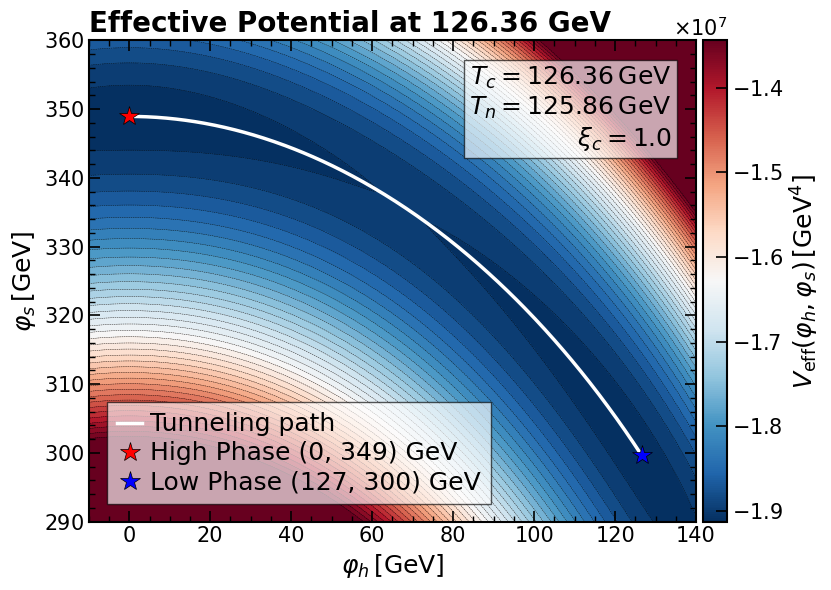

In [59]:
path_points = Trans['instanton'].Phi

# Grid in (h, s)
h_vals = np.linspace(-10, 140, 200)
s_vals = np.linspace(290, 360, 200)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.Vtot(X_grid, Tc).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 90))
V_shifted = V_plot - model.Vtot(np.array([[0.0, 0.0]]), Tc)

norm = Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=55, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=55, colors='k', linewidths=0.3, alpha=1)

ax.plot(path_points[:, 0], path_points[:, 1], label='Tunneling path', color='w', lw=2.5, ls='-')
ax.plot(path_points[-1, 0], path_points[-1, 1], 'r*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'High Phase ({path_points[-1, 0]:.0f}, {path_points[-1, 1]:.0f}) GeV')
ax.plot(path_points[0, 0], path_points[0, 1], 'b*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'Low Phase ({path_points[0, 0]:.0f}, {path_points[0, 1]:.0f}) GeV')

ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_\mathrm{eff}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower left", bbox_to_anchor=(0.01, 0.01), 
          ncol = 1, edgecolor="black", framealpha=0.65, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

annotation = (rf"$T_c   = {Tc:.2f} \, \mathrm{{GeV}}$"
              "\n"rf"$T_n = {Tn:.2f} \, \mathrm{{GeV}}$"
              "\n"rf"$\xi_c = {xic:.1f}$")
ax.text(0.96, 0.95, annotation,transform=ax.transAxes,fontsize=18,verticalalignment='top',horizontalalignment='right',
       bbox=dict(facecolor='white', edgecolor='black', alpha=0.65))

plt.title(rf"Effective Potential at {Tc:.2f} GeV", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(r"Figures\Tc_Contour.pdf", format="pdf", bbox_inches="tight")
plt.show()